# ECE1508 - Course Project
##  Federated Learning Architectures for WiFi-Based Human Activity Recognition

## 1. Setup & Imports

In [1]:
import numpy as np
import os
import glob
import networkx as nx
import copy
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset, Dataset, WeightedRandomSampler
from torchvision.models import resnet50, densenet121
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 2. Data Loading & Preprocessing

- Each sample is a CSI matrix of shape 1 × 250 × 90 (channels × time steps × subcarriers).
- Data are min-max normalised to [0, 1].
- There are 7 activity classes: lying down, falling, walking, running, sitting down, standing up, and background.

In [2]:
def load_UT_HAR(root_dir):
    expected = ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]
    data = {}
    for folder in ["data", "label"]:
        files = glob.glob(os.path.join(root_dir, folder, "*.csv"))
        for path in files:
            key = os.path.basename(path).split(".")[0]
            if key not in expected:
                continue
            arr = np.load(path, allow_pickle=True)
            if folder == "data":
                arr = arr.reshape(len(arr), 1, 250, 90)
                arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
                arr = torch.tensor(arr, dtype=torch.float32)
            else:
                arr = torch.tensor(arr, dtype=torch.long)
            data[key] = arr
    return data

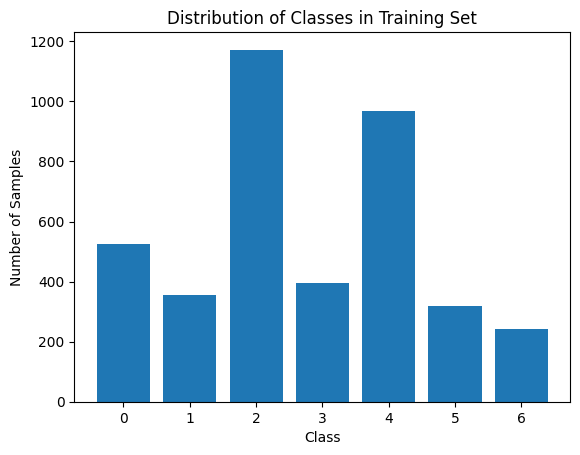

X_train shape: torch.Size([3977, 1, 250, 90])


In [3]:
wifi = load_UT_HAR("UT_HAR")

# Plot distribution of classes in training set
unique, counts = np.unique(wifi["y_train"].numpy(), return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Distribution of Classes in Training Set")
plt.show()

# Print shapes of datasets
print("X_train shape:", wifi["X_train"].shape)

- Dataset is relitively small and its distribution is imbalanced. We will use data augmentation and weighted sampler to increase the size of the training set and balance the classes.

In [4]:
class DataAugmentation:
    def __init__(self, noise=0.01, max_shift=5, scale_range=(0.9, 1.1)):
        self.noise = noise
        self.max_shift = max_shift
        self.scale_range = scale_range

    def __call__(self, x):
        x = x + self.noise * torch.randn_like(x)
        shift = torch.randint(-self.max_shift, self.max_shift + 1, (1,)).item()
        x = torch.roll(x, shifts=shift, dims=2)
        x = x * torch.empty(1).uniform_(*self.scale_range).item()
        return x

def expand_dataset(data, labels, augmenter, factor=1):
    augmented_data = []
    augmented_labels = []

    for _ in range(factor):
        for x, y in zip(data, labels):
            x_aug = augmenter(x)
            augmented_data.append(x_aug.unsqueeze(0))
            augmented_labels.append(y.unsqueeze(0))

    new_data = torch.cat([data] + augmented_data, dim=0)
    new_labels = torch.cat([labels] + augmented_labels, dim=0)
    return new_data, new_labels
    
def get_weight(labels):
    classes, counts = torch.unique(labels, return_counts=True)
    total_count = len(labels)
    class_weights = total_count / (len(classes) * counts.float())
    sample_weights = class_weights[labels]
    return sample_weights

def data_loader(data, labels, factor=0, batch_size=64, shuffle=True, augmenter=None):
    if augmenter is not None:
        data, labels = expand_dataset(data, labels, augmenter, factor=factor)
    dataset = TensorDataset(data, labels)
    if shuffle:
        sample_weights = get_weight(labels)
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
        return DataLoader(dataset, batch_size=batch_size, sampler=sampler)
    else:
        return DataLoader(dataset, batch_size=batch_size, shuffle=False)

In [5]:
augmenter = DataAugmentation(noise=0.02, max_shift=5, scale_range=(0.9, 1.1))

X_train, y_train = wifi['X_train'], wifi['y_train']
X_val, y_val = wifi['X_val'], wifi['y_val']
X_test, y_test = wifi['X_test'], wifi['y_test']

NUM_CLASSES = int(y_train.max().item()) + 1

train_loader = data_loader(X_train, y_train, factor=1, batch_size=64, shuffle=True, augmenter=augmenter)
val_loader = data_loader(X_val, y_val, batch_size=64, shuffle=False, augmenter=None)
test_loader = data_loader(X_test, y_test, batch_size=64, shuffle=False, augmenter=None)

Train batches: 125, Val batches: 8, Test batches: 8
Images shape: torch.Size([64, 1, 250, 90])
Labels shape: torch.Size([64])
Label values: tensor([0, 1, 2, 3, 4, 5, 6])


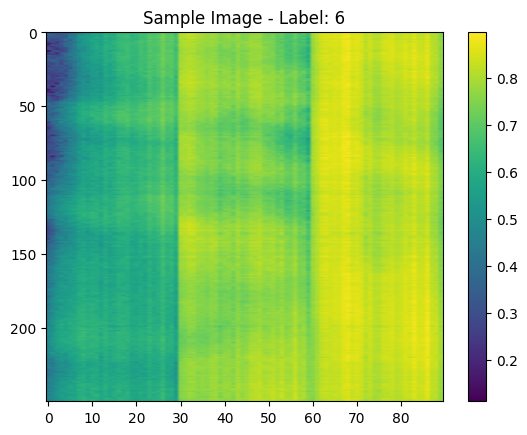

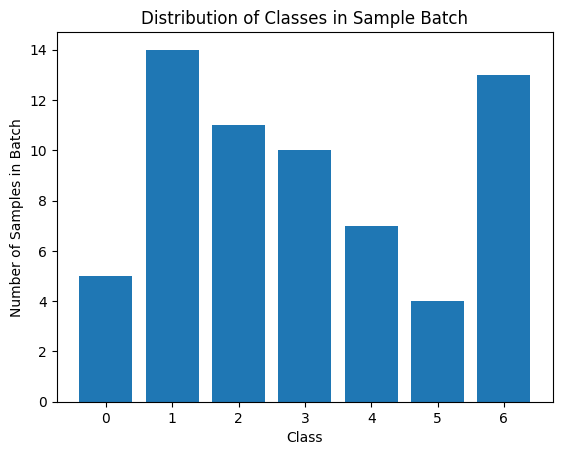

In [6]:
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

images, labels = next(iter(train_loader))
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Label values:", labels.unique())

sample_image, sample_label = images[0], labels[0]
plt.imshow(sample_image.squeeze(), aspect='auto', cmap='viridis')
plt.title(f"Sample Image - Label: {sample_label.item()}")
plt.colorbar()
plt.show()

batch_labels = labels.numpy()
unique, counts = np.unique(batch_labels, return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Number of Samples in Batch")
plt.title("Distribution of Classes in Sample Batch")
plt.show()

In [7]:
print("Dataset sizes")
print("Before augmentation - Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))
print("After augmentation - Train:", len(train_loader.dataset), "Val:", len(val_loader.dataset), "Test:", len(test_loader.dataset))

Dataset sizes
Before augmentation - Train: 3977 Val: 496 Test: 500
After augmentation - Train: 7954 Val: 496 Test: 500


## 3. Model Definitions

### 3.1. Custom CNN

In [8]:
class CNNModel(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 31 * 11, 128)
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.flatten(x)
        x = self.relu4(self.fc1(x))
        x = self.fc2(x)
        return x

### 3.2. ResNet-50

In [9]:
class ResNet50Model(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.base = resnet50(weights=None)
        self.base.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base.fc = nn.Linear(self.base.fc.in_features, num_classes)

    def forward(self, x):
        return self.base(x)

### 3.3. DenseNet-121

In [10]:
class DenseNetModel(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.base = densenet121(weights=None)
        self.base.features.conv0 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base.classifier = nn.Linear(self.base.classifier.in_features, num_classes)

    def forward(self, x):
        return self.base(x)

In [11]:
MODEL_BUILDERS = {
    'CNN': lambda: CNNModel(NUM_CLASSES),
    'ResNet50': lambda: ResNet50Model(NUM_CLASSES),
    'DenseNet': lambda: DenseNetModel(NUM_CLASSES),
}

MODELS = list(MODEL_BUILDERS.keys())

def count_params(model):
    return sum(p.numel() for p in model.parameters())

print('Model Parameter Counts')
for name, builder in MODEL_BUILDERS.items():
    m = builder()
    print(f'{name} params: {count_params(m)/1e6:.2f} M')

Model Parameter Counts
CNN params: 2.82 M
ResNet50 params: 23.52 M
DenseNet params: 6.95 M


## 4. Hyperparameter Tuning

In [12]:
def hyper_train(model, loader, epochs=3, lr=1e-3):
    
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    n_batches = 0
    train_acc = 0.0

    for epoch in range(epochs):
        correct = 0
        samples = 0
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            samples += y.size(0)
        train_acc = 100.0 * correct / max(samples, 1)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/n_batches:.4f}, Train Accuracy: {train_acc:.2f}%")

    return model, total_loss / max(n_batches, 1), train_acc

In [13]:
# Evaluation
@torch.no_grad()
def hyper_evaluate(model, loader):

    model.eval()
    all_preds = []
    all_labels = []
    loss = 0.0
    
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)
        loss += nn.CrossEntropyLoss()(outputs, y).item()
        preds = outputs.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc = 100.0 * (all_preds == all_labels).mean()
    return loss / len(loader), acc

In [14]:
cnn_model = CNNModel(num_classes=7).to(device)
cnn_train_loss = hyper_train(
    model=cnn_model,
    loader=train_loader,
    epochs=5,
    lr=0.001
)

cnn_test_loss, cnn_test_acc = hyper_evaluate(
    model=cnn_model,
    loader=val_loader,
)

print(f"Validation loss: {cnn_test_loss:.4f}, Validation accuracy: {cnn_test_acc:.2f}%")

Epoch 1/5 - Loss: 1.6344, Train Accuracy: 36.32%
Epoch 2/5 - Loss: 1.3567, Train Accuracy: 61.64%
Epoch 3/5 - Loss: 1.1556, Train Accuracy: 72.35%
Epoch 4/5 - Loss: 1.0149, Train Accuracy: 78.72%
Epoch 5/5 - Loss: 0.9003, Train Accuracy: 84.28%
Validation loss: 0.4918, Validation accuracy: 83.47%


### 4.1. Random Grid Search

In [15]:
def cnn_random_grid_search(options, model_name, num_trials):
    best_acc = 0
    best_config = None
    for trial in range(num_trials):
        t_lr = np.random.choice(options["lr_options"])
        t_batch_size = np.random.choice(options["batch_size_options"])
        t_epochs = np.random.choice(options["epoch_options"])

        print(f"\nTrial {trial+1}: lr={t_lr}, batch_size={t_batch_size}, epochs={t_epochs}")
        
        match model_name:
            case "cnn":
                model = CNNModel(num_classes=7).to(device)
            case "resnet":
                model = ResNet50Model(num_classes=7).to(device)
            case "densenet":
                model = DenseNetModel(num_classes=7).to(device)
        
        trial_train_dataset = data_loader(X_train, y_train, factor=1, batch_size=int(t_batch_size), shuffle=True, augmenter=augmenter)
        trial_val_dataset = data_loader(X_val, y_val, batch_size=int(t_batch_size), shuffle=False, augmenter=None)
        
        hyper_train(model=model, loader=trial_train_dataset, epochs=t_epochs, lr=t_lr)
        val_loss, val_acc = hyper_evaluate(model=model, loader=trial_val_dataset)
        
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2f}%")
        
        if val_acc > best_acc:
            best_acc = val_acc
            best_config = {"lr": t_lr, "batch_size": t_batch_size, "epochs": t_epochs}

    print(f"\nBest config: {best_config}, Validation Accuracy: {best_acc:.4f}")

In [16]:
options = {
    "lr_options": [0.0001, 0.0005, 0.001, 0.005, 0.01],
    "batch_size_options": [16, 32, 64, 128],
    "epoch_options": [5]
}
cnn_random_grid_search(options, "cnn", num_trials=10)


Trial 1: lr=0.005, batch_size=16, epochs=5
Epoch 1/5 - Loss: 1.9539, Train Accuracy: 14.58%
Epoch 2/5 - Loss: 1.9502, Train Accuracy: 14.36%
Epoch 3/5 - Loss: 1.9490, Train Accuracy: 14.65%
Epoch 4/5 - Loss: 1.9485, Train Accuracy: 14.16%
Epoch 5/5 - Loss: 1.9481, Train Accuracy: 14.68%
Validation Loss: 1.9372, Validation Accuracy: 29.44%

Trial 2: lr=0.001, batch_size=128, epochs=5
Epoch 1/5 - Loss: 1.6735, Train Accuracy: 34.99%
Epoch 2/5 - Loss: 1.4742, Train Accuracy: 54.78%
Epoch 3/5 - Loss: 1.3031, Train Accuracy: 65.35%
Epoch 4/5 - Loss: 1.1771, Train Accuracy: 72.16%
Epoch 5/5 - Loss: 1.0636, Train Accuracy: 78.22%
Validation Loss: 0.5702, Validation Accuracy: 79.44%

Trial 3: lr=0.01, batch_size=16, epochs=5
Epoch 1/5 - Loss: 1.9843, Train Accuracy: 14.29%
Epoch 2/5 - Loss: 1.9659, Train Accuracy: 13.65%
Epoch 3/5 - Loss: 1.9598, Train Accuracy: 13.99%
Epoch 4/5 - Loss: 1.9568, Train Accuracy: 13.78%
Epoch 5/5 - Loss: 1.9549, Train Accuracy: 14.65%
Validation Loss: 1.9380, Va

- Among the tested hyperparameter configurations, a learning rate of 0.001 with batch size 32 was selected as the optimal setting. Although a higher learning rate (0.005) achieved slightly better peak validation accuracy, the configuration with 0.001 provided more stable and consistent training behavior, making it a more reliable choice for downstream experiments.

- Higher learning rates (0.01) failed to converge, while very low learning rates (0.0001) resulted in slow learning and underfitting. The learning rate of 0.001 achieved a strong balance between convergence speed and stability.

In [17]:
def cnn_grid_search(options, model_name):
    best_acc = 0
    best_config = None
    trial = 0
    total_trials = len(options["lr_options"]) * len(options["batch_size_options"]) * len(options["epoch_options"])
    for t_lr in options["lr_options"]:
        for t_batch_size in options["batch_size_options"]:
            for t_epochs in options["epoch_options"]:
                trial += 1
                print(f"\nTrial {trial}/{total_trials}: lr={t_lr}, batch_size={t_batch_size}, epochs={t_epochs}")
        
                match model_name:
                    case "cnn":
                        model = CNNModel(num_classes=7).to(device)
                    case "resnet":
                        model = ResNet50Model(num_classes=7).to(device)
                    case "densenet":
                        model = DenseNetModel(num_classes=7).to(device)
                
                trial_train_dataset = data_loader(X_train, y_train, factor=1, batch_size=int(t_batch_size), shuffle=True, augmenter=augmenter)
                trial_val_dataset = data_loader(X_val, y_val, batch_size=int(t_batch_size), shuffle=False, augmenter=None)
                
                hyper_train(model=model, loader=trial_train_dataset, epochs=t_epochs, lr=t_lr)
                val_loss, val_acc = hyper_evaluate(model=model, loader=trial_val_dataset)
                
                print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2f}%")
                
                if val_acc > best_acc:
                    best_acc = val_acc
                    best_config = {"lr": t_lr, "batch_size": t_batch_size, "epochs": t_epochs}

    print(f"\nBest config: {best_config}, Validation Accuracy: {best_acc:.4f}")

In [18]:
options = {
    "lr_options": [0.0001, 0.0005, 0.001, 0.005, 0.01],
    "batch_size_options": [16, 32, 64, 128],
    "epoch_options": [5]
}
cnn_grid_search(options, "cnn")


Trial 1/20: lr=0.0001, batch_size=16, epochs=5
Epoch 1/5 - Loss: 1.7164, Train Accuracy: 33.64%
Epoch 2/5 - Loss: 1.5327, Train Accuracy: 51.99%
Epoch 3/5 - Loss: 1.3924, Train Accuracy: 60.36%
Epoch 4/5 - Loss: 1.2806, Train Accuracy: 67.24%
Epoch 5/5 - Loss: 1.1953, Train Accuracy: 70.71%
Validation Loss: 0.7636, Validation Accuracy: 72.58%

Trial 2/20: lr=0.0001, batch_size=32, epochs=5
Epoch 1/5 - Loss: 1.8818, Train Accuracy: 21.80%
Epoch 2/5 - Loss: 1.6776, Train Accuracy: 46.73%
Epoch 3/5 - Loss: 1.5408, Train Accuracy: 55.78%
Epoch 4/5 - Loss: 1.4341, Train Accuracy: 61.03%
Epoch 5/5 - Loss: 1.3413, Train Accuracy: 66.51%
Validation Loss: 0.8675, Validation Accuracy: 70.56%

Trial 3/20: lr=0.0001, batch_size=64, epochs=5
Epoch 1/5 - Loss: 1.8829, Train Accuracy: 24.49%
Epoch 2/5 - Loss: 1.7180, Train Accuracy: 44.77%
Epoch 3/5 - Loss: 1.5848, Train Accuracy: 53.09%
Epoch 4/5 - Loss: 1.4886, Train Accuracy: 58.11%
Epoch 5/5 - Loss: 1.4150, Train Accuracy: 61.00%
Validation Loss

In [12]:
train_loader = data_loader(X_train, y_train, factor=0, batch_size=32, shuffle=True, augmenter=augmenter)
test_loader = data_loader(X_test, y_test, batch_size=32, shuffle=False, augmenter=None)

In [21]:
cnn_model = CNNModel(num_classes=7).to(device)
cnn_train_loss = hyper_train(
    model=cnn_model,
    loader=train_loader,
    epochs=5,
    lr=0.001
)

cnn_test_loss, cnn_test_acc = hyper_evaluate(
    model=cnn_model,
    loader=test_loader,
)

print(f"Test loss: {cnn_test_loss:.4f}, Test accuracy: {cnn_test_acc:.2f}%")

Epoch 1/5 - Loss: 1.6377, Train Accuracy: 36.18%
Epoch 2/5 - Loss: 1.3657, Train Accuracy: 60.30%
Epoch 3/5 - Loss: 1.1511, Train Accuracy: 73.02%
Epoch 4/5 - Loss: 0.9806, Train Accuracy: 83.51%
Epoch 5/5 - Loss: 0.8532, Train Accuracy: 87.30%
Test loss: 0.4780, Test accuracy: 81.80%


In [22]:
resnet_model = ResNet50Model(num_classes=7).to(device)
resnet_train_loss = hyper_train(
    model=resnet_model,
    loader=train_loader,
    epochs=5,
    lr=0.001
)

resnet_test_loss, resnet_test_acc = hyper_evaluate(
    model=resnet_model,
    loader=test_loader,
)

print(f"Test loss: {resnet_test_loss:.4f}, Test accuracy: {resnet_test_acc:.2f}%")

Epoch 1/5 - Loss: 0.9594, Train Accuracy: 67.97%
Epoch 2/5 - Loss: 0.6962, Train Accuracy: 85.82%
Epoch 3/5 - Loss: 0.5657, Train Accuracy: 90.04%
Epoch 4/5 - Loss: 0.4837, Train Accuracy: 92.58%
Epoch 5/5 - Loss: 0.4156, Train Accuracy: 95.10%
Test loss: 0.6228, Test accuracy: 79.40%


In [23]:
densenet_model = DenseNetModel(num_classes=7).to(device)
densenet_train_loss = hyper_train(
    model=densenet_model,
    loader=train_loader,
    epochs=5,
    lr=0.001
)

densenet_test_loss, densenet_test_acc = hyper_evaluate(
    model=densenet_model,
    loader=test_loader,
)

print(f"Test loss: {densenet_test_loss:.4f}, Test accuracy: {densenet_test_acc:.2f}%")

Epoch 1/5 - Loss: 0.8012, Train Accuracy: 70.88%
Epoch 2/5 - Loss: 0.5995, Train Accuracy: 86.47%
Epoch 3/5 - Loss: 0.4838, Train Accuracy: 91.45%
Epoch 4/5 - Loss: 0.4098, Train Accuracy: 93.69%
Epoch 5/5 - Loss: 0.3644, Train Accuracy: 93.59%
Test loss: 1.0750, Test accuracy: 69.80%


## 5. Utility Functions

In [13]:
# Local training step
def train_local(model, loader, epochs=3, lr=1e-3):
    
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    n_batches = 0
    train_acc = 0.0

    for epoch in range(epochs):
        correct = 0
        samples = 0
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            samples += y.size(0)
        train_acc = 100.0 * correct / max(samples, 1)

    return model, total_loss / max(n_batches, 1), train_acc

In [14]:
# Evaluation
@torch.no_grad()
def evaluate(model, loader):

    model.eval()
    all_preds = []
    all_labels = []
    
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        preds = model(X).argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc = 100.0 * (all_preds == all_labels).mean()
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return acc, f1

In [15]:
# FedAvg aggregation
def fedavg_aggregate(global_model, client_models, weights=None):

    K = len(client_models)
    if weights is None:
        weights = [1.0 / K] * K
    global_sd = global_model.state_dict()
    client_sds = [m.state_dict() for m in client_models]
    for key in global_sd:
        if global_sd[key].dtype.is_floating_point:
            global_sd[key] = sum(w * sd[key] for w, sd in zip(weights, client_sds))
        else:
            global_sd[key] = client_sds[0][key]
    global_model.load_state_dict(global_sd)
    return global_model

In [16]:
# Communication cost
def model_size_M(model):
    return count_params(model) / 1e6

## 6. Client Data Partitioning

- The training set is split into K equal IID partitions, one per client.

In [17]:
def iid_partition(dataset, K, batch_size=64):

    n = len(dataset)
    indices = torch.randperm(n).tolist()
    splits = np.array_split(indices, K)
    loaders = []
    for idx in splits:
        subset = Subset(dataset, idx.tolist())
        loaders.append(DataLoader(subset, batch_size=batch_size, shuffle=True))
    return loaders

## 7. Centralized Federated Learning (FedAvg)

- Protocol per round:
  1. Broadcast global model to all K clients.
  2. Each client trains locally for E epochs.
  3. Server collects and averages all client models.
- Communication cost per round: 2 × K × |θ| (K uploads + K downloads).

In [18]:
def run_fedavg(model_name, K=10, T=10, E=3, batch_size=64, lr=1e-3):

    client_loaders = iid_partition(train_loader.dataset, K, batch_size)
    global_model = MODEL_BUILDERS[model_name]().to(device)
    params = model_size_M(global_model)
    comm_per_round = 2 * K * params

    round_local_train_acc = []
    round_global_train_acc = []
    round_acc = []
    round_f1 = []

    for t in range(1, T + 1):
        client_models = []
        client_train_accs = []
        for loader in client_loaders:
            client = copy.deepcopy(global_model)
            client, _, train_acc = train_local(client, loader, epochs=E, lr=lr)
            client_models.append(client)
            client_train_accs.append(train_acc)

        global_model = fedavg_aggregate(global_model, client_models)
        local_avg_train_acc = sum(client_train_accs) / len(client_train_accs)
        global_train_acc, _ = evaluate(global_model, train_loader)
        acc, f1 = evaluate(global_model, test_loader)

        round_local_train_acc.append(local_avg_train_acc)
        round_global_train_acc.append(global_train_acc)
        round_acc.append(acc)
        round_f1.append(f1)
        print(
            f'Round {t:2d}/{T}  '
            f'LocalAvgTrain={local_avg_train_acc:.2f}%  '
            f'GlobalTrain={global_train_acc:.2f}%  '
            f'GlobalTest={acc:.2f}%  '
            f'F1={f1:.4f}'
        )

    total_comm = comm_per_round * T
    print(f'Total comm cost: {total_comm:.1f} M params')

    return {
        'round_local_train_acc': round_local_train_acc,
        'round_global_train_acc': round_global_train_acc,
        'round_acc': round_acc,
        'round_f1': round_f1,
        'final_acc': round_acc[-1],
        'final_f1': round_f1[-1],
        'comm_M': total_comm,
        'model': global_model
    }

### 7.1. Run Experiments
- **Experiment Configuration**
  - K: Total number of clients
  - T: Number of global communication rounds
  - E: Local training epochs per round per client
  - batch_size: Mini-batch size during local training
  - lr: Learning rate for Adam optimiser

In [28]:
K_values = [5, 10]
lr_values = [0.001, 0.0005, 0.0001]
T = 10
E = 5
batch_size = 32

fedavg_grid = {}
print(f'Grid Search Config: K={K_values}, lr={lr_values}, T={T}, E={E}, batch_size={batch_size}')

Grid Search Config: K=[5, 10], lr=[0.001, 0.0005, 0.0001], T=10, E=5, batch_size=32


- **Model Training**

In [29]:
fedavg_grid['CNN'] = {}
for K in K_values:
    fedavg_grid['CNN'][K] = {}
    for lr in lr_values:
        print('-' * 60)
        print(f'Model=CNN  K={K}  lr={lr}')
        fedavg_grid['CNN'][K][lr] = run_fedavg('CNN', K=K, T=T, E=E, batch_size=batch_size, lr=lr)

------------------------------------------------------------
Model=CNN  K=5  lr=0.001
Round  1/10  LocalAvgTrain=56.25%  GlobalTrain=32.56%  GlobalTest=47.00%  F1=0.3044
Round  2/10  LocalAvgTrain=73.27%  GlobalTrain=69.25%  GlobalTest=67.00%  F1=0.6199
Round  3/10  LocalAvgTrain=87.28%  GlobalTrain=84.56%  GlobalTest=80.80%  F1=0.7743
Round  4/10  LocalAvgTrain=93.86%  GlobalTrain=91.05%  GlobalTest=86.40%  F1=0.8342
Round  5/10  LocalAvgTrain=96.15%  GlobalTrain=94.39%  GlobalTest=88.80%  F1=0.8576
Round  6/10  LocalAvgTrain=98.82%  GlobalTrain=96.83%  GlobalTest=91.20%  F1=0.8882
Round  7/10  LocalAvgTrain=99.02%  GlobalTrain=98.11%  GlobalTest=92.80%  F1=0.8990
Round  8/10  LocalAvgTrain=98.94%  GlobalTrain=98.62%  GlobalTest=93.60%  F1=0.9112
Round  9/10  LocalAvgTrain=98.94%  GlobalTrain=98.87%  GlobalTest=94.00%  F1=0.9168
Round 10/10  LocalAvgTrain=99.09%  GlobalTrain=98.94%  GlobalTest=94.40%  F1=0.9226
Total comm cost: 282.3 M params
------------------------------------------

In [31]:
fedavg_grid['ResNet50'] = {}
for K in K_values:
    fedavg_grid['ResNet50'][K] = {}
    for lr in lr_values:
        print('-' * 60)
        print(f'Model=ResNet50  K={K}  lr={lr}')
        fedavg_grid['ResNet50'][K][lr] = run_fedavg('ResNet50', K=K, T=T, E=E, batch_size=batch_size, lr=lr)

------------------------------------------------------------
Model=ResNet50  K=5  lr=0.001
Round  1/10  LocalAvgTrain=82.30%  GlobalTrain=14.33%  GlobalTest=6.20%  F1=0.0167
Round  2/10  LocalAvgTrain=86.75%  GlobalTrain=40.03%  GlobalTest=37.20%  F1=0.2749
Round  3/10  LocalAvgTrain=88.38%  GlobalTrain=56.40%  GlobalTest=64.80%  F1=0.4606
Round  4/10  LocalAvgTrain=88.38%  GlobalTrain=81.14%  GlobalTest=83.00%  F1=0.7825
Round  5/10  LocalAvgTrain=93.84%  GlobalTrain=67.59%  GlobalTest=72.00%  F1=0.6927
Round  6/10  LocalAvgTrain=93.64%  GlobalTrain=91.45%  GlobalTest=89.80%  F1=0.8813
Round  7/10  LocalAvgTrain=96.20%  GlobalTrain=73.45%  GlobalTest=70.60%  F1=0.6931
Round  8/10  LocalAvgTrain=94.97%  GlobalTrain=72.94%  GlobalTest=72.60%  F1=0.7345
Round  9/10  LocalAvgTrain=96.88%  GlobalTrain=96.10%  GlobalTest=93.40%  F1=0.9128
Round 10/10  LocalAvgTrain=96.81%  GlobalTrain=32.86%  GlobalTest=43.80%  F1=0.3797
Total comm cost: 2351.6 M params
-------------------------------------

In [32]:
fedavg_grid['DenseNet'] = {}
for K in K_values:
    fedavg_grid['DenseNet'][K] = {}
    for lr in lr_values:
        print('-' * 60)
        print(f'Model=DenseNet  K={K}  lr={lr}')
        fedavg_grid['DenseNet'][K][lr] = run_fedavg('DenseNet', K=K, T=T, E=E, batch_size=batch_size, lr=lr)

------------------------------------------------------------
Model=DenseNet  K=5  lr=0.001
Round  1/10  LocalAvgTrain=85.57%  GlobalTrain=31.46%  GlobalTest=46.80%  F1=0.2359
Round  2/10  LocalAvgTrain=88.21%  GlobalTrain=71.94%  GlobalTest=75.00%  F1=0.7030
Round  3/10  LocalAvgTrain=92.61%  GlobalTrain=90.12%  GlobalTest=89.40%  F1=0.8737
Round  4/10  LocalAvgTrain=93.74%  GlobalTrain=87.13%  GlobalTest=82.80%  F1=0.8084
Round  5/10  LocalAvgTrain=96.30%  GlobalTrain=88.56%  GlobalTest=85.40%  F1=0.8539
Round  6/10  LocalAvgTrain=97.28%  GlobalTrain=94.37%  GlobalTest=91.80%  F1=0.9141
Round  7/10  LocalAvgTrain=97.74%  GlobalTrain=82.07%  GlobalTest=77.80%  F1=0.7983
Round  8/10  LocalAvgTrain=97.54%  GlobalTrain=93.14%  GlobalTest=90.00%  F1=0.8881
Round  9/10  LocalAvgTrain=98.09%  GlobalTrain=91.30%  GlobalTest=83.60%  F1=0.8371
Round 10/10  LocalAvgTrain=97.94%  GlobalTrain=97.91%  GlobalTest=96.60%  F1=0.9556
Total comm cost: 695.5 M params
-------------------------------------

### 7.2. Results & Visualisation

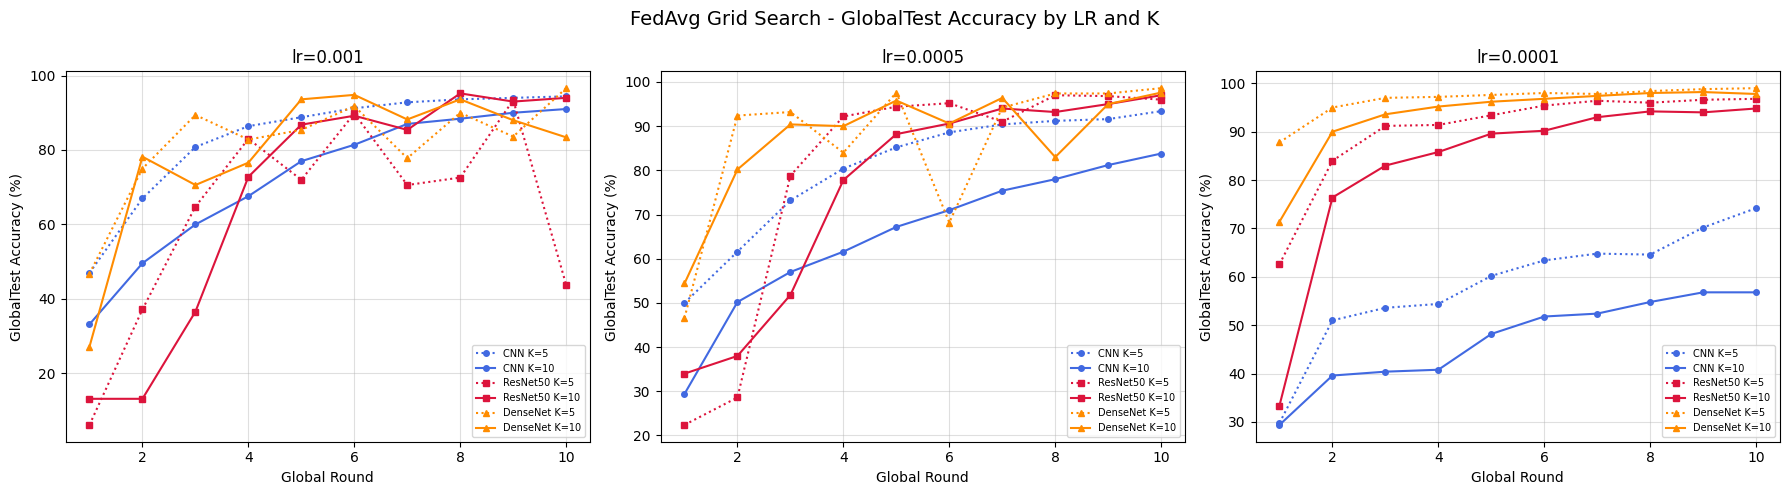

In [43]:
rounds = list(range(1, T + 1))
colors = {'CNN': 'royalblue', 'ResNet50': 'crimson', 'DenseNet': 'darkorange'}
markers = {'CNN': 'o', 'ResNet50': 's', 'DenseNet': '^'}
linestyles = {5: ':', 10: '-'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, lr in zip(axes, lr_values):
    for model_name in MODELS:
        for K in K_values:
            r = fedavg_grid[model_name][K][lr]
            ax.plot(
                rounds, r['round_acc'],
                color=colors[model_name],
                linestyle=linestyles[K],
                marker=markers[model_name],
                markersize=4,
                label=f'{model_name} K={K}'
            )
    ax.set_title(f'lr={lr}', fontsize=12)
    ax.set_xlabel('Global Round')
    ax.set_ylabel('GlobalTest Accuracy (%)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.4)

plt.suptitle('FedAvg Grid Search - GlobalTest Accuracy by LR and K', fontsize=14)
plt.tight_layout()
plt.show()


- Summary table

In [34]:
print('FedAvg Grid Search - Final Results Summary')
print(f"{'Model':<12} {'K':>4} {'LR':>8} {'Acc (%)':>8} {'Macro-F1':>10} {'Comm (M params)':>18}")
print('-' * 64)
for K in K_values:
    for model_name in MODELS:
        for lr in lr_values:
            r = fedavg_grid[model_name][K][lr]
            print(f"{model_name:<12} {K:>4} {lr:>8.4f} {r['final_acc']:>8.2f} {r['final_f1']:>10.4f} {r['comm_M']:>18.1f}")
    print('-' * 64)

FedAvg Grid Search - Final Results Summary
Model           K       LR  Acc (%)   Macro-F1    Comm (M params)
----------------------------------------------------------------
CNN             5   0.0010    94.40     0.9226              282.3
CNN             5   0.0005    93.40     0.9096              282.3
CNN             5   0.0001    74.20     0.6951              282.3
ResNet50        5   0.0010    43.80     0.3797             2351.6
ResNet50        5   0.0005    96.00     0.9475             2351.6
ResNet50        5   0.0001    96.80     0.9565             2351.6
DenseNet        5   0.0010    96.60     0.9556              695.5
DenseNet        5   0.0005    98.60     0.9763              695.5
DenseNet        5   0.0001    99.00     0.9828              695.5
----------------------------------------------------------------
CNN            10   0.0010    91.00     0.8804              564.5
CNN            10   0.0005    83.80     0.8040              564.5
CNN            10   0.0001    56.80

- Best config

In [35]:
# Find best (K, lr) per model by final test accuracy
best_config = {}
for model_name in MODELS:
    best_acc = -1
    for K in K_values:
        for lr in lr_values:
            r = fedavg_grid[model_name][K][lr]
            if r['final_acc'] > best_acc:
                best_acc = r['final_acc']
                best_config[model_name] = {'K': K, 'lr': lr}

for model_name in MODELS:
    cfg = best_config[model_name]
    print(f"{model_name}: best K={cfg['K']}, lr={cfg['lr']}")


CNN: best K=5, lr=0.001
ResNet50: best K=10, lr=0.0005
DenseNet: best K=5, lr=0.0001


- Convergence plots: LocalAvgTrain, GlobalTrain, GlobalTest

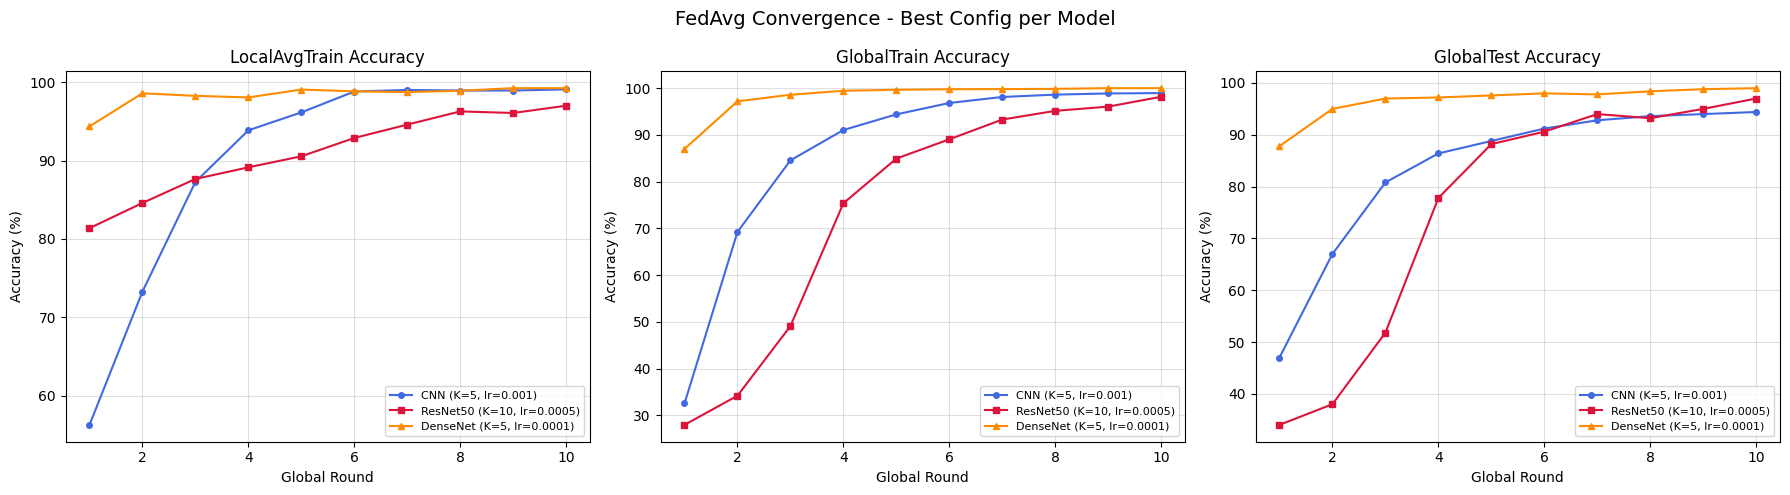

In [ ]:
rounds = list(range(1, T + 1))
colors = {'CNN': 'royalblue', 'ResNet50': 'crimson', 'DenseNet': 'darkorange'}
markers = {'CNN': 'o', 'ResNet50': 's', 'DenseNet': '^'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
titles = ['LocalAvgTrain Accuracy', 'GlobalTrain Accuracy', 'GlobalTest Accuracy']
keys = ['round_local_train_acc', 'round_global_train_acc', 'round_acc']

for ax, title, key in zip(axes, titles, keys):
    for model_name in MODELS:
        cfg = best_config[model_name]
        r = fedavg_grid[model_name][cfg['K']][cfg['lr']]
        label = f"{model_name} (K={cfg['K']}, lr={cfg['lr']})"
        ax.plot(rounds, r[key], color=colors[model_name], marker=markers[model_name], markersize=4, label=label)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Global Round')
    ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.suptitle('FedAvg Convergence - Best Config per Model', fontsize=14)
plt.tight_layout()
plt.show()

- Macro-F1 convergence

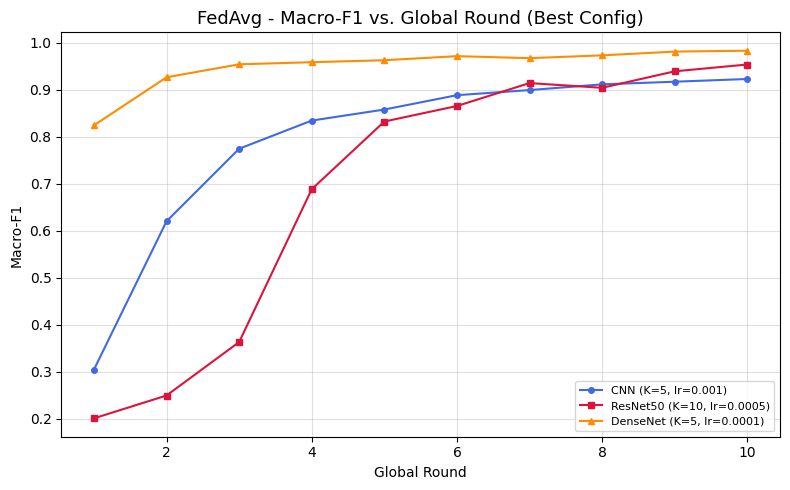

In [45]:
fig, ax = plt.subplots(figsize=(8, 5))
for model_name in MODELS:
    cfg = best_config[model_name]
    r = fedavg_grid[model_name][cfg['K']][cfg['lr']]
    label = f"{model_name} (K={cfg['K']}, lr={cfg['lr']})"
    ax.plot(rounds, r['round_f1'], color=colors[model_name], marker=markers[model_name], markersize=4, label=label)

ax.set_title('FedAvg - Macro-F1 vs. Global Round (Best Config)', fontsize=13)
ax.set_xlabel('Global Round')
ax.set_ylabel('Macro-F1')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 8. Decentralized Federated Learning (Graph-based)
- Protocol per round:
  1. Each client sends its current model to its two neighbors in the ring.
  2. Each client receives models from its neighbors and aggregates them (e.g., FedAvg with self + neighbors).
  3. Each client trains locally for E epochs using its updated model.
- Communication cost per round: 2 × K × |θ| (each client uploads 2 times to both its neighbors).

In [46]:
def create_graph(num_clients):
    G = nx.Graph()
    # Add client nodes
    for i in range(num_clients):
        G.add_node(f'Client {i+1}')
    # Add ring edges
    for i in range(num_clients):
        G.add_edge(f'Client {i+1}', f'Client {(i+2) % num_clients + 1}')
    return G

In [47]:
def run_ring_fedavg(model_name, K=10, T=10, E=3, batch_size=64, lr=1e-3):

    client_loaders = iid_partition(train_loader.dataset, K, batch_size)
    initial_model = MODEL_BUILDERS[model_name]().to(device)
    params = model_size_M(initial_model)
    comm_per_round = 2 * K * params

    G = create_graph(K)
    
    client_models = []
    round_acc = []
    round_train_acc = []
    round_f1 = []

    for t in range(1, T + 1):
        client_train_accs = 0.0
        client_test_accs = 0.0
        client_test_f1s = 0.0
        
        if t == 1:
            init_client_train_accs = 0.0
            # Each client trains on its local data and sends model to neighbors
            for loader in client_loaders:
                client = copy.deepcopy(initial_model)
                client, _, train_acc = train_local(client, loader, epochs=E, lr=lr)
                client_models.append(client)
                init_client_train_accs += train_acc
            
        # Each client aggregates models from neighbors and updates its model
        for node in G.nodes:
            neighbors = list(G.neighbors(node))
            neighbor_indexes = [int(n.split()[1]) - 1 for n in neighbors]
            neighbor_models = [client_models[i] for i in neighbor_indexes]
            idx = int(node.split()[1]) - 1
            client_models[idx] = fedavg_aggregate(client_models[idx], neighbor_models)
            
        # Train each client on its local data with the aggregated model
        for model in client_models:
            idx = client_models.index(model)
            loader = client_loaders[idx]
            model, _, train_acc = train_local(model, loader, epochs=E, lr=lr)
            client_train_accs += train_acc

        # Evaluate client's model on test set
        for model in client_models:
            acc, f1 = evaluate(model, test_loader)
            client_test_accs += acc
            client_test_f1s += f1
        
        round_acc.append(client_test_accs / K)
        round_f1.append(client_test_f1s / K)
        round_train_acc.append(client_train_accs / K)

        if t == 1:
             print(
                f'Round {t:2d}/{T}  '
                f'InitClientAvgTrain={init_client_train_accs/K:.2f}%  '
                f'ClientAvgTrain={client_train_accs/K:.2f}%  '
                f'ClientAvgTest={round_acc[-1]:.2f}%  '
                f'F1={round_f1[-1]:.4f}'
            )
        else:
            print(
                f'Round {t:2d}/{T}  '
                f'ClientAvgTrain={client_train_accs/K:.2f}%  '
                f'ClientAvgTest={round_acc[-1]:.2f}%  '
                f'F1={round_f1[-1]:.4f}'
            )

    total_comm = comm_per_round * T
    print(f'Total comm cost: {total_comm:.1f} M params')

    return {
        'round_train_acc': round_train_acc,
        'round_acc': round_acc,
        'round_f1': round_f1,
        'final_acc': round_acc[-1],
        'final_f1': round_f1[-1],
        'comm_M': total_comm,
    }

### 8.1. Run Experiments
- **Experiment Configuration**
  - K: Total number of clients
  - T: Number of global communication rounds
  - E: Local training epochs per round per client
  - batch_size: Mini-batch size during local training
  - lr: Learning rate for Adam optimiser

In [48]:
K_values = [5, 10]
lr_values = [0.001, 0.0005, 0.0001]
T = 10
E = 5
batch_size = 32

ring_grid = {}

print(f'Grid Search Config: K={K_values}, lr={lr_values}, T={T}, E={E}, batch_size={batch_size}')

Grid Search Config: K=[5, 10], lr=[0.001, 0.0005, 0.0001], T=10, E=5, batch_size=32


- **Model Training**

In [49]:
ring_grid['CNN'] = {}
for K in K_values:
    ring_grid['CNN'][K] = {}
    for lr in lr_values:
        print('-' * 60)
        print(f'Model=CNN  K={K}  lr={lr}')
        ring_grid['CNN'][K][lr] = run_ring_fedavg('CNN', K=K, T=T, E=E, batch_size=batch_size, lr=lr)

------------------------------------------------------------
Model=CNN  K=5  lr=0.001
Round  1/10  InitClientAvgTrain=57.63%  ClientAvgTrain=76.59%  ClientAvgTest=69.28%  F1=0.6371
Round  2/10  ClientAvgTrain=90.29%  ClientAvgTest=79.92%  F1=0.7544
Round  3/10  ClientAvgTrain=95.78%  ClientAvgTest=85.52%  F1=0.8231
Round  4/10  ClientAvgTrain=97.54%  ClientAvgTest=87.60%  F1=0.8478
Round  5/10  ClientAvgTrain=98.34%  ClientAvgTest=89.24%  F1=0.8599
Round  6/10  ClientAvgTrain=98.11%  ClientAvgTest=90.08%  F1=0.8744
Round  7/10  ClientAvgTrain=99.17%  ClientAvgTest=90.56%  F1=0.8800
Round  8/10  ClientAvgTrain=99.35%  ClientAvgTest=92.04%  F1=0.8942
Round  9/10  ClientAvgTrain=99.75%  ClientAvgTest=92.32%  F1=0.8967
Round 10/10  ClientAvgTrain=98.99%  ClientAvgTest=92.00%  F1=0.8888
Total comm cost: 282.3 M params
------------------------------------------------------------
Model=CNN  K=5  lr=0.0005
Round  1/10  InitClientAvgTrain=52.15%  ClientAvgTrain=66.26%  ClientAvgTest=61.00%  F1=

In [50]:
ring_grid['ResNet50'] = {}
for K in K_values:
    ring_grid['ResNet50'][K] = {}
    for lr in lr_values:
        print('-' * 60)
        print(f'Model=ResNet50  K={K}  lr={lr}')
        ring_grid['ResNet50'][K][lr] = run_ring_fedavg('ResNet50', K=K, T=T, E=E, batch_size=batch_size, lr=lr)

------------------------------------------------------------
Model=ResNet50  K=5  lr=0.001
Round  1/10  InitClientAvgTrain=81.97%  ClientAvgTrain=85.39%  ClientAvgTest=51.48%  F1=0.4304
Round  2/10  ClientAvgTrain=89.87%  ClientAvgTest=55.08%  F1=0.4951
Round  3/10  ClientAvgTrain=91.40%  ClientAvgTest=67.40%  F1=0.5880
Round  4/10  ClientAvgTrain=91.35%  ClientAvgTest=61.92%  F1=0.5523
Round  5/10  ClientAvgTrain=94.37%  ClientAvgTest=59.12%  F1=0.5272
Round  6/10  ClientAvgTrain=94.14%  ClientAvgTest=56.60%  F1=0.4593
Round  7/10  ClientAvgTrain=95.37%  ClientAvgTest=67.24%  F1=0.6355
Round  8/10  ClientAvgTrain=95.45%  ClientAvgTest=59.68%  F1=0.5830
Round  9/10  ClientAvgTrain=97.36%  ClientAvgTest=63.56%  F1=0.5656
Round 10/10  ClientAvgTrain=96.68%  ClientAvgTest=53.84%  F1=0.4780
Total comm cost: 2351.6 M params
------------------------------------------------------------
Model=ResNet50  K=5  lr=0.0005
Round  1/10  InitClientAvgTrain=86.67%  ClientAvgTrain=90.17%  ClientAvgTest=

In [51]:
ring_grid['DenseNet'] = {}
for K in K_values:
    ring_grid['DenseNet'][K] = {}
    for lr in lr_values:
        print('-' * 60)
        print(f'Model=DenseNet  K={K}  lr={lr}')
        ring_grid['DenseNet'][K][lr] = run_ring_fedavg('DenseNet', K=K, T=T, E=E, batch_size=batch_size, lr=lr)

------------------------------------------------------------
Model=DenseNet  K=5  lr=0.001
Round  1/10  InitClientAvgTrain=85.97%  ClientAvgTrain=90.24%  ClientAvgTest=51.24%  F1=0.4150
Round  2/10  ClientAvgTrain=94.02%  ClientAvgTest=45.08%  F1=0.3431
Round  3/10  ClientAvgTrain=95.20%  ClientAvgTest=65.56%  F1=0.6304
Round  4/10  ClientAvgTrain=95.60%  ClientAvgTest=42.28%  F1=0.2811
Round  5/10  ClientAvgTrain=96.73%  ClientAvgTest=58.32%  F1=0.5387
Round  6/10  ClientAvgTrain=97.13%  ClientAvgTest=43.32%  F1=0.3130
Round  7/10  ClientAvgTrain=97.54%  ClientAvgTest=63.72%  F1=0.5924
Round  8/10  ClientAvgTrain=98.49%  ClientAvgTest=61.96%  F1=0.4949
Round  9/10  ClientAvgTrain=98.57%  ClientAvgTest=72.68%  F1=0.6742
Round 10/10  ClientAvgTrain=97.96%  ClientAvgTest=63.96%  F1=0.5330
Total comm cost: 695.5 M params
------------------------------------------------------------
Model=DenseNet  K=5  lr=0.0005
Round  1/10  InitClientAvgTrain=89.09%  ClientAvgTrain=93.56%  ClientAvgTest=6

### 8.2. Results & Visualisation

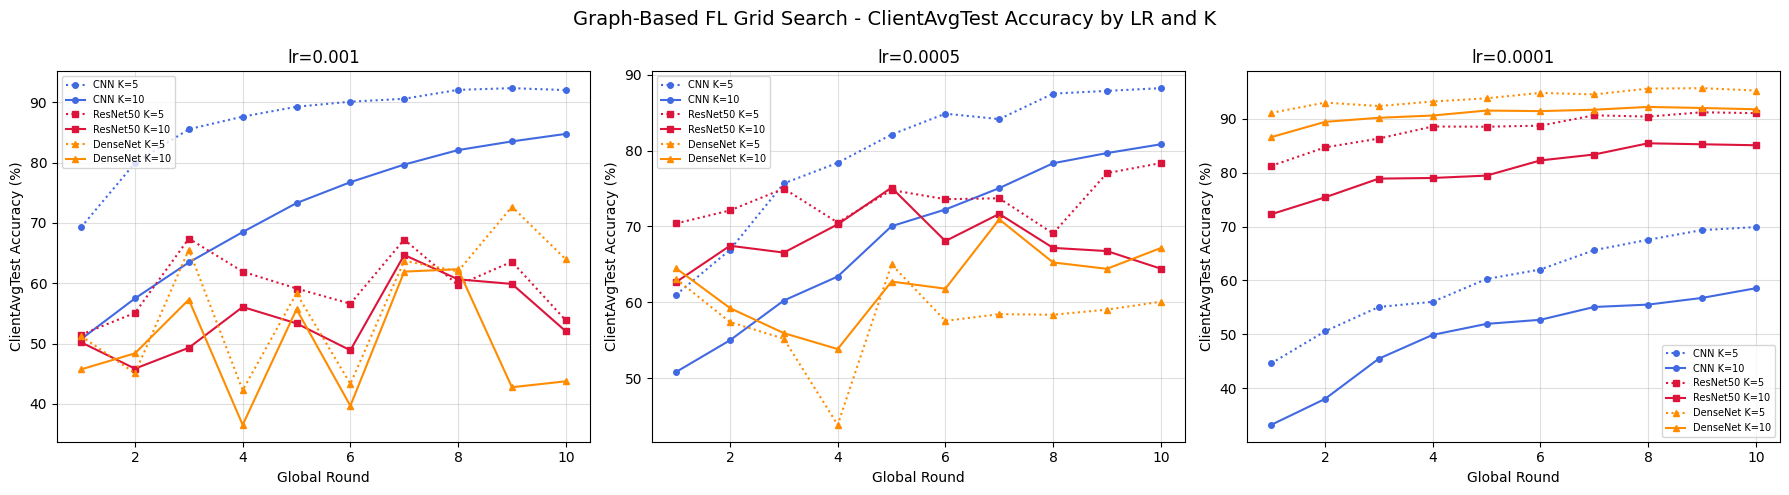

In [52]:
rounds = list(range(1, T + 1))
colors = {'CNN': 'royalblue', 'ResNet50': 'crimson', 'DenseNet': 'darkorange'}
markers = {'CNN': 'o', 'ResNet50': 's', 'DenseNet': '^'}
linestyles = {5: ':', 10: '-'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, lr in zip(axes, lr_values):
    for model_name in MODELS:
        for K in K_values:
            r = ring_grid[model_name][K][lr]
            ax.plot(
                rounds, r['round_acc'],
                color=colors[model_name],
                linestyle=linestyles[K],
                marker=markers[model_name],
                markersize=4,
                label=f'{model_name} K={K}'
            )
    ax.set_title(f'lr={lr}', fontsize=12)
    ax.set_xlabel('Global Round')
    ax.set_ylabel('ClientAvgTest Accuracy (%)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.4)

plt.suptitle('Graph-Based FL Grid Search - ClientAvgTest Accuracy by LR and K', fontsize=14)
plt.tight_layout()
plt.show()

- Summary table

In [53]:
print('Graph-Based FL Grid Search - Final Results Summary')
print(f"{'Model':<12} {'K':>4} {'LR':>8} {'Acc (%)':>8} {'Macro-F1':>10} {'Comm (M params)':>18}")
print('-' * 64)
for K in K_values:
    for model_name in MODELS:
        for lr in lr_values:
            r = ring_grid[model_name][K][lr]
            print(f"{model_name:<12} {K:>4} {lr:>8.4f} {r['final_acc']:>8.2f} {r['final_f1']:>10.4f} {r['comm_M']:>18.1f}")
    print('-' * 64)

Graph-Based FL Grid Search - Final Results Summary
Model           K       LR  Acc (%)   Macro-F1    Comm (M params)
----------------------------------------------------------------
CNN             5   0.0010    92.00     0.8888              282.3
CNN             5   0.0005    88.24     0.8525              282.3
CNN             5   0.0001    69.92     0.6518              282.3
ResNet50        5   0.0010    53.84     0.4780             2351.6
ResNet50        5   0.0005    78.36     0.7112             2351.6
ResNet50        5   0.0001    91.08     0.8851             2351.6
DenseNet        5   0.0010    63.96     0.5330              695.5
DenseNet        5   0.0005    60.08     0.5803              695.5
DenseNet        5   0.0001    95.28     0.9296              695.5
----------------------------------------------------------------
CNN            10   0.0010    84.74     0.8082              564.5
CNN            10   0.0005    80.84     0.7754              564.5
CNN            10   0.0001 

- Best config

In [54]:
best_config_ring = {}
for model_name in MODELS:
    best_acc = -1
    for K in K_values:
        for lr in lr_values:
            r = ring_grid[model_name][K][lr]
            if r['final_acc'] > best_acc:
                best_acc = r['final_acc']
                best_config_ring[model_name] = {'K': K, 'lr': lr}

for model_name in MODELS:
    cfg = best_config_ring[model_name]
    print(f"{model_name}: best K={cfg['K']}, lr={cfg['lr']}")

CNN: best K=5, lr=0.001
ResNet50: best K=5, lr=0.0001
DenseNet: best K=5, lr=0.0001


- Convergence plots: ClientAvgTrain, ClientAvgTest

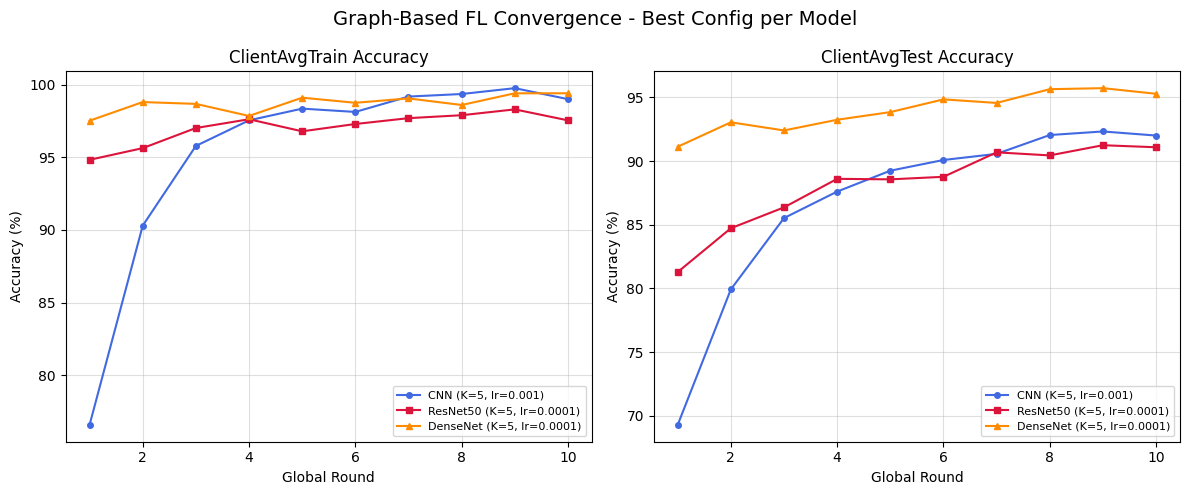

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
titles = ['ClientAvgTrain Accuracy', 'ClientAvgTest Accuracy']
keys = ['round_train_acc', 'round_acc']

for ax, title, key in zip(axes, titles, keys):
    for model_name in MODELS:
        cfg = best_config_ring[model_name]
        r = ring_grid[model_name][cfg['K']][cfg['lr']]
        label = f"{model_name} (K={cfg['K']}, lr={cfg['lr']})"
        ax.plot(rounds, r[key], color=colors[model_name], marker=markers[model_name], markersize=4, label=label)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Global Round')
    ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.suptitle('Graph-Based FL Convergence - Best Config per Model', fontsize=14)
plt.tight_layout()
plt.show()

- Macro-F1 convergence

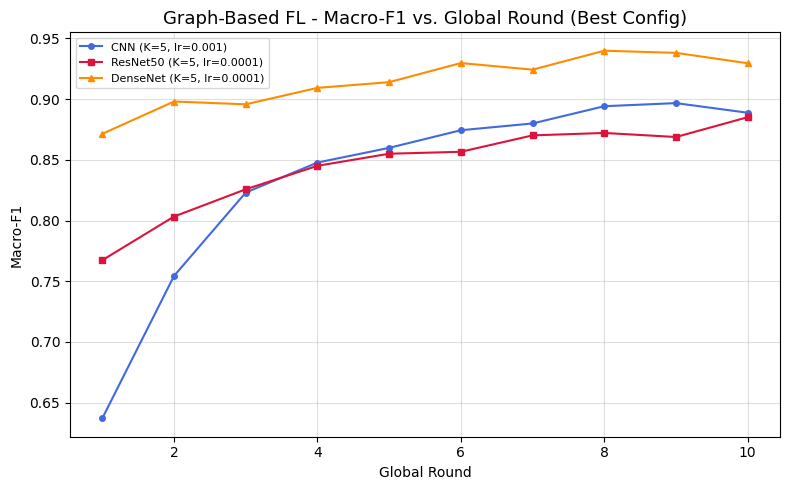

In [56]:
fig, ax = plt.subplots(figsize=(8, 5))
for model_name in MODELS:
    cfg = best_config_ring[model_name]
    r = ring_grid[model_name][cfg['K']][cfg['lr']]
    label = f"{model_name} (K={cfg['K']}, lr={cfg['lr']})"
    ax.plot(rounds, r['round_f1'], color=colors[model_name], marker=markers[model_name], markersize=4, label=label)

ax.set_title('Graph-Based FL - Macro-F1 vs. Global Round (Best Config)', fontsize=13)
ax.set_xlabel('Global Round')
ax.set_ylabel('Macro-F1')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
